In [2]:
import sys
import os

# Add project root to Python path
sys.path.append(os.path.abspath(".."))

In [3]:
pip install networkx    

python(61031) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.


In [4]:
import networkx as nx
from src.build_network import build_user_network

### Small Grpah


In [5]:
small_graph = build_user_network(
    "../data/raw/wikidata_small.csv"
)

print("Small Graph")
print("Nodes:", small_graph.number_of_nodes())
print("Edges:", small_graph.number_of_edges())
print("Density:", nx.density(small_graph))

Small Graph
Nodes: 552
Edges: 2425
Density: 0.015945974381230438


In [6]:
print("Connected components:", nx.number_connected_components(small_graph))
print("Average degree:", sum(dict(small_graph.degree()).values()) / small_graph.number_of_nodes())

Connected components: 29
Average degree: 8.78623188405797


### Medium Graph

In [7]:
medium_graph = build_user_network(
    "../data/raw/wikidata_medium.csv"
)

print("Medium Graph")
print("Nodes:", medium_graph.number_of_nodes())
print("Edges:", medium_graph.number_of_edges())
print("Density:", nx.density(medium_graph))
print("Connected components:", nx.number_connected_components(medium_graph))
print("Average degree:", sum(dict(medium_graph.degree()).values()) / medium_graph.number_of_nodes())

Medium Graph
Nodes: 2258
Edges: 11915
Density: 0.004675935864133747
Connected components: 97
Average degree: 10.553587245349867


### Large Graph

In [8]:
large_graph = build_user_network(
    "../data/raw/wikidata_large.csv",
    max_thread_size=300   # safety cap
)

print("Large Graph")
print("Nodes:", large_graph.number_of_nodes())
print("Edges:", large_graph.number_of_edges())
print("Density:", nx.density(large_graph))
print("Connected components:", nx.number_connected_components(large_graph))
print("Average degree:", sum(dict(large_graph.degree()).values()) / large_graph.number_of_nodes())

Large Graph
Nodes: 11387
Edges: 24692
Density: 0.00038089543160109467
Connected components: 3262
Average degree: 4.336875384210064


In [9]:
nx.write_gml(small_graph, "../outputs/graphs/small_graph.gml")
nx.write_gml(medium_graph, "../outputs/graphs/medium_graph.gml")
nx.write_gml(large_graph, "../outputs/graphs/large_graph.gml")

### LARGE COMPONENT SIZE

In [10]:
def largest_component_size(G):
    return len(max(nx.connected_components(G), key=len))

print("Largest CC Small:", largest_component_size(small_graph))
print("Largest CC Medium:", largest_component_size(medium_graph))
print("Largest CC Large:", largest_component_size(large_graph))


Largest CC Small: 519
Largest CC Medium: 2159
Largest CC Large: 7767


### Network Visualisations

In [ ]:
print("\n--- Network Visualisations ---")

for name, G_lcc in [("small", small_lcc), ("medium", medium_lcc), ("large", large_lcc)]:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    if G_lcc.number_of_nodes() > 1000:
        # For large network, sample 500 nodes for visualisation
        sampled_nodes = random.sample(list(G_lcc.nodes()), 500)
        G_sub = G_lcc.subgraph(sampled_nodes).copy()
        title_suffix = " (500-node sample)"
    else:
        G_sub = G_lcc
        title_suffix = ""

    pos = nx.spring_layout(G_sub, seed=42, k=0.4)
    node_sizes = [10 + 5 * G_sub.degree(n) for n in G_sub.nodes()]
    
    nx.draw_networkx_nodes(G_sub, pos, node_size=node_sizes,
                           node_color='steelblue', alpha=0.7, ax=ax)
    nx.draw_networkx_edges(G_sub, pos, alpha=0.15,
                           edge_color='grey', ax=ax)
    
    ax.set_title(f'{name.title()} Network LCC '
                 f'({G_lcc.number_of_nodes()} nodes, {G_lcc.number_of_edges()} edges)'
                 f'{title_suffix}')
    ax.axis('off')
    plt.tight_layout()
    outpath = f'{OUT}/{name}_network_viz.png'
    plt.savefig(outpath, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  Saved {outpath}")


--- Task A Fix 1: Network Visualisations ---
  Saved outputs/figures/small_network_viz.png
  Saved outputs/figures/medium_network_viz.png
  Saved outputs/figures/large_network_viz.png


# Part 1- Task B: Network Metrics

In [ ]:
import networkx as nx

small_graph = nx.read_gml("../outputs/graphs/small_graph.gml")
medium_graph = nx.read_gml("../outputs/graphs/medium_graph.gml")
large_graph = nx.read_gml("../outputs/graphs/large_graph.gml")

In [ ]:
def get_lcc(G):
    largest_cc = max(nx.connected_components(G), key=len)
    return G.subgraph(largest_cc).copy()

In [ ]:
small_lcc = get_lcc(small_graph)
medium_lcc = get_lcc(medium_graph)
large_lcc = get_lcc(large_graph)

print("Small LCC size:", small_lcc.number_of_nodes())
print("Medium LCC size:", medium_lcc.number_of_nodes())
print("Large LCC size:", large_lcc.number_of_nodes())

Small LCC size: 519
Medium LCC size: 2159
Large LCC size: 7767


In [ ]:
def compute_metrics(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    density = nx.density(G)
    avg_clustering = nx.average_clustering(G)
    avg_path_length = nx.average_shortest_path_length(G)
    diameter = nx.diameter(G)

    return {
        "Nodes": n,
        "Edges": m,
        "Density": density,
        "Avg Clustering": avg_clustering,
        "Avg Path Length": avg_path_length,
        "Diameter": diameter
    }

In [ ]:
small_metrics = compute_metrics(small_lcc)
medium_metrics = compute_metrics(medium_lcc)
large_metrics = compute_metrics(large_lcc)

print("Small:", small_metrics)
print("Medium:", medium_metrics)
print("Large:", large_metrics)

Small: {'Nodes': 519, 'Edges': 2418, 'Density': 0.017988260762827238, 'Avg Clustering': 0.6878027878267541, 'Avg Path Length': 2.60271088594788, 'Diameter': 6}
Medium: {'Nodes': 2159, 'Edges': 11912, 'Density': 0.0051134097797825425, 'Avg Clustering': 0.6479479442102378, 'Avg Path Length': 2.794136749370375, 'Diameter': 6}
Large: {'Nodes': 7767, 'Edges': 24219, 'Density': 0.0008030369179138706, 'Avg Clustering': 0.24408169819487496, 'Avg Path Length': 3.63558102434937, 'Diameter': 10}


In [ ]:
def random_comparison(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    p = (2 * m) / (n * (n - 1))

    G_rand = nx.erdos_renyi_graph(n, p)

    rand_clustering = nx.average_clustering(G_rand)

    # ensure connected for path length
    largest_cc_rand = max(nx.connected_components(G_rand), key=len)
    G_rand_lcc = G_rand.subgraph(largest_cc_rand)

    rand_path_length = nx.average_shortest_path_length(G_rand_lcc)

    return {
        "Rand Clustering": rand_clustering,
        "Rand Path Length": rand_path_length
    }

In [ ]:
print("Small Random:", random_comparison(small_lcc))
print("Medium Random:", random_comparison(medium_lcc))
print("Large Random:", random_comparison(large_lcc))

Small Random: {'Rand Clustering': 0.014983587233448533, 'Rand Path Length': 3.0818770876574346}
Medium Random: {'Rand Clustering': 0.0048542573834918406, 'Rand Path Length': 3.470091575193781}
Large Random: {'Rand Clustering': 0.0009682433784403646, 'Rand Path Length': 5.080274815865831}


In [ ]:
def small_world_coefficient(real_metrics, rand_metrics):
    C = real_metrics["Avg Clustering"]
    L = real_metrics["Avg Path Length"]
    C_rand = rand_metrics["Rand Clustering"]
    L_rand = rand_metrics["Rand Path Length"]

    return (C / C_rand) / (L / L_rand)

print("Small S:", small_world_coefficient(small_metrics, random_comparison(small_lcc)))
print("Medium S:", small_world_coefficient(medium_metrics, random_comparison(medium_lcc)))
print("Large S:", small_world_coefficient(large_metrics, random_comparison(large_lcc)))

Small S: 47.64091060031297
Medium S: 157.3438584823891
Large S: 439.66949724346676


### Directed Edge Definition (Small)

In [ ]:
print("\n--- Directed Edge Definition (Small) ---")

G_directed = nx.DiGraph()
for thread_id, group in small_df.groupby('thread_id'):
    users = list(group['username'])
    if len(users) < 2:
        continue
    initiator = users[0]
    for responder in users[1:]:
        if initiator != responder:
            if G_directed.has_edge(initiator, responder):
                G_directed[initiator][responder]['weight'] += 1
            else:
                G_directed.add_edge(initiator, responder, weight=1)

print(f"  Directed graph: {G_directed.number_of_nodes()} nodes, {G_directed.number_of_edges()} edges")
in_deg = nx.in_degree_centrality(G_directed)
top5_in = sorted(in_deg.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"  Top-5 by in-degree centrality:")
for user, val in top5_in:
    print(f"    {user}: {val:.4f}")

### We need to check:

Is it heavy-tailed?

Are there hubs?

Does it resemble scale-free behaviour?

In [ ]:
pip install matplotlib


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 80.1 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 78.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 90.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


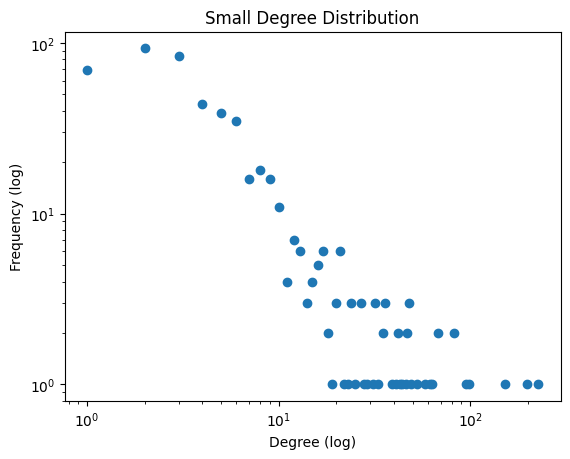

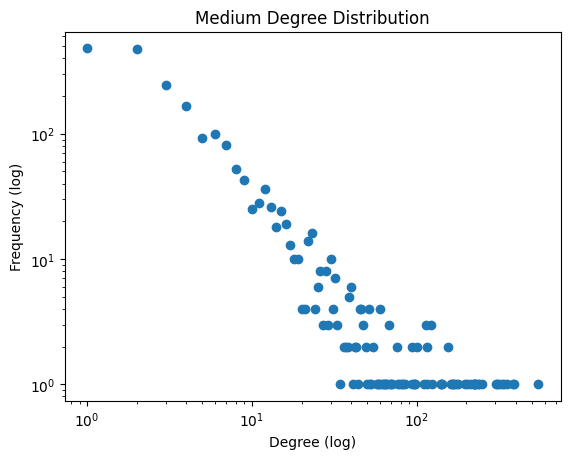

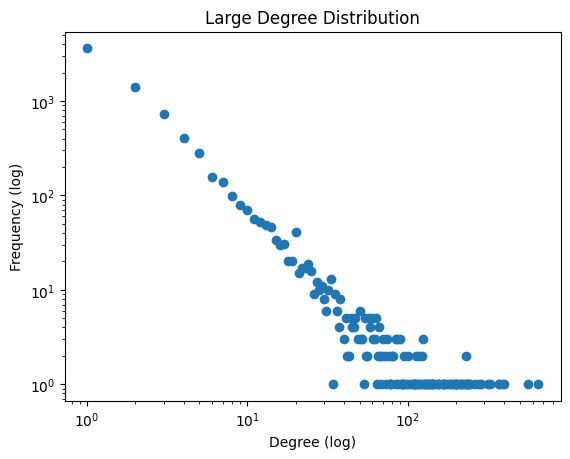

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_degree_loglog(G, title):
    degrees = [d for n, d in G.degree()]
    degree_count = np.bincount(degrees)
    deg = np.nonzero(degree_count)[0]

    plt.figure()
    plt.loglog(deg, degree_count[deg], marker='o', linestyle='None')
    plt.title(title)
    plt.xlabel("Degree (log)")
    plt.ylabel("Frequency (log)")
    plt.show()

plot_degree_loglog(small_lcc, "Small Degree Distribution")
plot_degree_loglog(medium_lcc, "Medium Degree Distribution")
plot_degree_loglog(large_lcc, "Large Degree Distribution")

### (Task A Visualisations, Transitivity, Power-law)

In [15]:
import sys, os, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter


# ────────────────────────────────────────────
# Helper: build network (same as src/build_network.py)
# ────────────────────────────────────────────
def build_user_network(file_path, max_thread_size=None):
    df = pd.read_csv(file_path)
    df["thread_id"] = df["page_name"].astype(str) + "||" + df["thread_subject"].astype(str)
    G = nx.Graph()
    users = df["username"].unique()
    G.add_nodes_from(users)
    for thread, group in df.groupby("thread_id"):
        thread_users = group["username"].unique()
        if max_thread_size and len(thread_users) > max_thread_size:
            continue
        for u1, u2 in combinations(thread_users, 2):
            if G.has_edge(u1, u2):
                G[u1][u2]["weight"] += 1
            else:
                G.add_edge(u1, u2, weight=1)
    return G, df

def get_lcc(G):
    largest_cc = max(nx.connected_components(G), key=len)
    return G.subgraph(largest_cc).copy()

OUT = "outputs/figures"
os.makedirs(OUT, exist_ok=True)

# ════════════════════════════════════════════
# PART 1 — Wikidata Editor Network
# ════════════════════════════════════════════

print("="*60)
print("PART 1: Building networks…")
print("="*60)

small_graph, small_df = build_user_network("../data/raw/wikidata_small.csv")
medium_graph, medium_df = build_user_network("../data/raw/wikidata_medium.csv")
large_graph, large_df = build_user_network("../data/raw/wikidata_large.csv", max_thread_size=300)

small_lcc = get_lcc(small_graph)
medium_lcc = get_lcc(medium_graph)
large_lcc = get_lcc(large_graph)

print(f"Small  LCC: {small_lcc.number_of_nodes()} nodes, {small_lcc.number_of_edges()} edges")
print(f"Medium LCC: {medium_lcc.number_of_nodes()} nodes, {medium_lcc.number_of_edges()} edges")
print(f"Large  LCC: {large_lcc.number_of_nodes()} nodes, {large_lcc.number_of_edges()} edges")

# ──────────────────────────────────────
# Task A Fix 1 — Network Visualisations
# ──────────────────────────────────────
print("\n--- Task A Fix 1: Network Visualisations ---")

for name, G_lcc in [("small", small_lcc), ("medium", medium_lcc), ("large", large_lcc)]:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    if G_lcc.number_of_nodes() > 1000:
        # For large network, sample 500 nodes for visualisation
        sampled_nodes = random.sample(list(G_lcc.nodes()), 500)
        G_sub = G_lcc.subgraph(sampled_nodes).copy()
        title_suffix = " (500-node sample)"
    else:
        G_sub = G_lcc
        title_suffix = ""

    pos = nx.spring_layout(G_sub, seed=42, k=0.4)
    node_sizes = [10 + 5 * G_sub.degree(n) for n in G_sub.nodes()]
    
    nx.draw_networkx_nodes(G_sub, pos, node_size=node_sizes,
                           node_color='steelblue', alpha=0.7, ax=ax)
    nx.draw_networkx_edges(G_sub, pos, alpha=0.15,
                           edge_color='grey', ax=ax)
    
    ax.set_title(f'{name.title()} Network LCC '
                 f'({G_lcc.number_of_nodes()} nodes, {G_lcc.number_of_edges()} edges)'
                 f'{title_suffix}')
    ax.axis('off')
    plt.tight_layout()
    outpath = f'{OUT}/{name}_network_viz.png'
    plt.savefig(outpath, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  Saved {outpath}")

# ──────────────────────────────────────
# Task A Fix 2 — Directed Edge Definition
# ──────────────────────────────────────
print("\n--- Task A Fix 2: Directed Edge Definition (Small) ---")

G_directed = nx.DiGraph()
for thread_id, group in small_df.groupby('thread_id'):
    users = list(group['username'])
    if len(users) < 2:
        continue
    initiator = users[0]
    for responder in users[1:]:
        if initiator != responder:
            if G_directed.has_edge(initiator, responder):
                G_directed[initiator][responder]['weight'] += 1
            else:
                G_directed.add_edge(initiator, responder, weight=1)

print(f"  Directed graph: {G_directed.number_of_nodes()} nodes, {G_directed.number_of_edges()} edges")
in_deg = nx.in_degree_centrality(G_directed)
top5_in = sorted(in_deg.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"  Top-5 by in-degree centrality:")
for user, val in top5_in:
    print(f"    {user}: {val:.4f}")

# ──────────────────────────────────────
# Task B Fix — Transitivity + Power-law
# ──────────────────────────────────────
print("\n--- Task B Fix: Transitivity + Power-law ---")

transitivity_results = {}
for name, G in [('Small', small_lcc), ('Medium', medium_lcc), ('Large', large_lcc)]:
    real_trans = nx.transitivity(G)
    n = G.number_of_nodes()
    p = nx.density(G)
    G_rand = nx.erdos_renyi_graph(n, p, seed=42)
    rand_trans = nx.transitivity(G_rand)
    transitivity_results[name] = (real_trans, rand_trans)
    print(f"  {name}: Real transitivity={real_trans:.4f}, Random transitivity={rand_trans:.4f}")

# Power-law fit for small network
degrees = [d for _, d in small_lcc.degree()]
deg_counts = Counter(degrees)
xs = sorted(deg_counts.keys())
ys = [deg_counts[x] for x in xs]
log_x = np.log10([x for x in xs if x > 0])
log_y = np.log10([deg_counts[x] for x in xs if x > 0])
slope, intercept = np.polyfit(log_x, log_y, 1)
print(f"  Small network power-law exponent (slope): {slope:.2f}")



PART 1: Building networks…
Small  LCC: 519 nodes, 2418 edges
Medium LCC: 2159 nodes, 11912 edges
Large  LCC: 7767 nodes, 24219 edges

--- Task A Fix 1: Network Visualisations ---
  Saved outputs/figures/small_network_viz.png
  Saved outputs/figures/medium_network_viz.png
  Saved outputs/figures/large_network_viz.png

--- Task A Fix 2: Directed Edge Definition (Small) ---
  Directed graph: 527 nodes, 1394 edges
  Top-5 by in-degree centrality:
    Pasleim: 0.2624
    Jura1: 0.1597
    Matěj Suchánek: 0.1274
    ValterVB: 0.0798
    Ricordisamoa: 0.0684

--- Task B Fix: Transitivity + Power-law ---
  Small: Real transitivity=0.1745, Random transitivity=0.0161
  Medium: Real transitivity=0.1390, Random transitivity=0.0049
  Large: Real transitivity=0.0777, Random transitivity=0.0009
  Small network power-law exponent (slope): -1.07
